## **Remaining Useful Life (RUL) of Turbofan Engines Prediction Model**

### Importing Libraries

In [ ]:
!pip install numpy pandas matplotlib seaborn scikit-learn tensorflow

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense,Dropout,SimpleRNN
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

### Loading the Dataset

In [ ]:
train_df = pd.read_csv(
    "train_FD001.txt",
    sep=" ",
    header=None
)
test_df = pd.read_csv(
    "test_FD001.txt",
    sep=" ",
    header=None
)
test_df = test_df.drop(columns=[26, 27])

# Load true RUL labels (one value per test engine = RUL at last cycle)
rul_test = pd.read_csv(
    "RUL_FD001.txt",
    header=None,
    names=["true_RUL"]
)

print("Test engines:", test_df[0].nunique())
print("True RUL labels:", len(rul_test))

Test engines: 100
True RUL labels: 100


In [ ]:
train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,NaN,NaN
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,NaN,NaN
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,NaN,NaN
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,NaN,NaN


In [ ]:
train_df.shape

(20631, 28)

### Checking for Missing Values

In [ ]:
train_df.isnull().sum()

,0
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


In [ ]:
train_df = train_df.drop(columns=[26, 27])

In [ ]:
train_df.shape

(20631, 26)

### Naming the Columns

In [ ]:
columns = ["unit", "cycle"] + \
          [f"setting{i}" for i in range(1, 4)] + \
          [f"sensor{i}" for i in range(1, 22)]

train_df.columns = columns
test_df.columns  = columns

In [ ]:
train_df.head()

,unit,cycle,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [ ]:
train_df["unit"].nunique()

100

### Computing RUL Labels


For each engine at each cycle, we calculate how many cycles it has left before failure

In [ ]:
rul_df = train_df.groupby("unit")["cycle"].max().reset_index()
rul_df.columns = ["unit", "max_cycle"]

rul_df.head()

,unit,max_cycle
0,1,192
1,2,287
2,3,179
3,4,189
4,5,269


In [ ]:
train_df = train_df.merge(rul_df, on="unit", how="left")

train_df.head()

,unit,cycle,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21,max_cycle
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192


### Piecewise Linear RUL
In the CMAPSS FD001 dataset, most engines survive for around 125–200 cycles. Studies and experiments on this dataset have shown that engines don't show any real signs of wear or degradation in their early healthy phase — all sensor readings look almost identical. So the first chunk of an engine's life gives the model no useful pattern to learn from. To fix this, we "chop" the RUL curve — instead of letting it start from 200 or 300, we flatten the top at 125. This is called Piecewise Linear RUL — the RUL stays flat at 125 during the healthy phase, then starts counting down linearly as the engine begins to degrade. The other common approach is Linear RUL, where RUL simply counts down from the very first cycle — but this confuses the model because early cycles look healthy yet get different RUL labels. Piecewise linear is preferred because it only asks the model to learn from cycles where something is actually changing.

In [ ]:
train_df["RUL"] = train_df["max_cycle"] - train_df["cycle"]
train_df["RUL"] = train_df["RUL"].clip(upper=125)

train_df.head()

,unit,cycle,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21,max_cycle,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,125
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,125
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,125
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,125
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,125


In [ ]:
train_df[["unit", "cycle", "max_cycle", "RUL"]].head()

,unit,cycle,max_cycle,RUL
0,1,1,192,125
1,1,2,192,125
2,1,3,192,125
3,1,4,192,125
4,1,5,192,125


In [ ]:
train_df = train_df.drop(columns=["max_cycle"])

### Plots

### Engine Lifetime Distribution

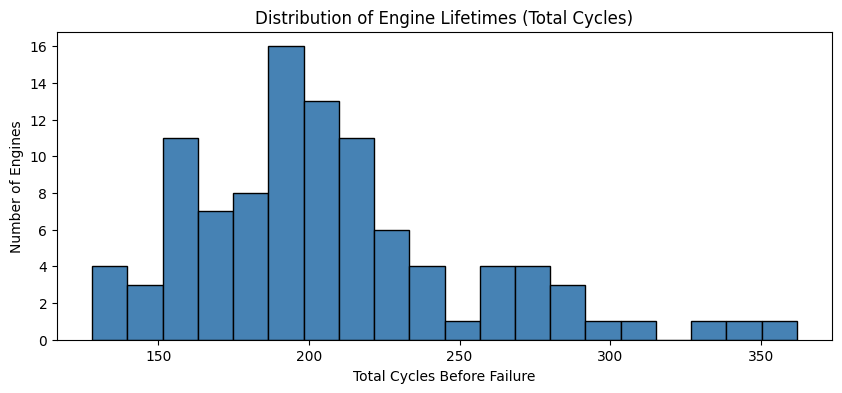

Average engine life: 206.3 cycles
Min: 128, Max: 362


In [ ]:
max_cycles = train_df.groupby('unit')['cycle'].max()

plt.figure(figsize=(10, 4))
plt.hist(max_cycles, bins=20, color='steelblue', edgecolor='black')
plt.title('Distribution of Engine Lifetimes (Total Cycles)')
plt.xlabel('Total Cycles Before Failure')
plt.ylabel('Number of Engines')
plt.show()

print(f"Average engine life: {max_cycles.mean():.1f} cycles")
print(f"Min: {max_cycles.min()}, Max: {max_cycles.max()}")

This histogram shows how long different engines survived before failing. It helps us understand the spread of our data — do all engines fail around the same time, or is there a lot of variation?

### Sensor Degradation Over Time

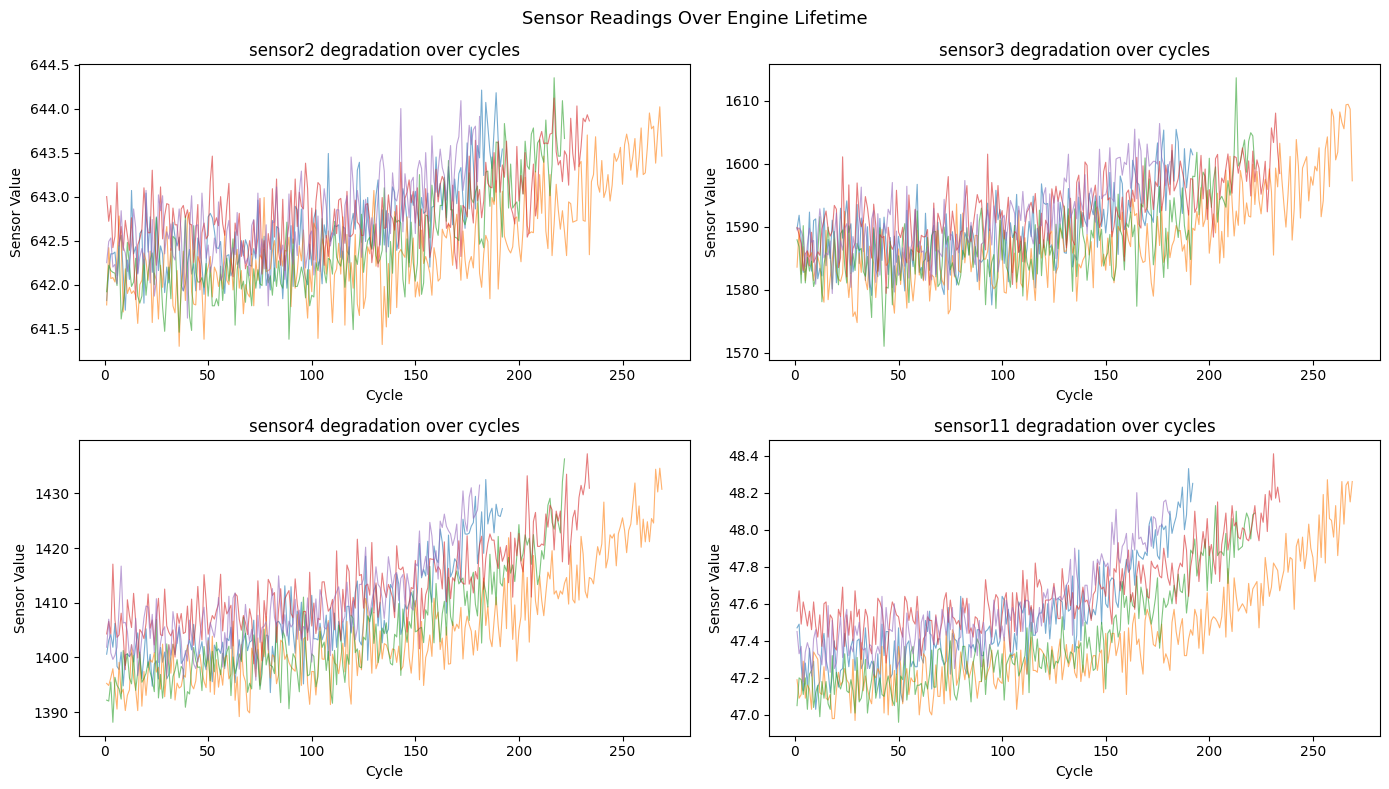

In [ ]:
# Shows how sensors change as engine approaches failure
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, sensor in zip(axes.flatten(), ['sensor2', 'sensor3', 'sensor4', 'sensor11']):
    for unit in [1, 5, 10, 20, 35]:
        d = train_df[train_df['unit'] == unit]
        ax.plot(d['cycle'], d[sensor], alpha=0.6, linewidth=0.8)
    ax.set_title(f'{sensor} degradation over cycles')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('Sensor Value')

plt.suptitle('Sensor Readings Over Engine Lifetime', fontsize=13)
plt.tight_layout()
plt.show()

These plots show how key sensors change as an engine approaches failure. A sensor that trends upward or downward over time is a good predictor of remaining life.

### Correlation Heatmap

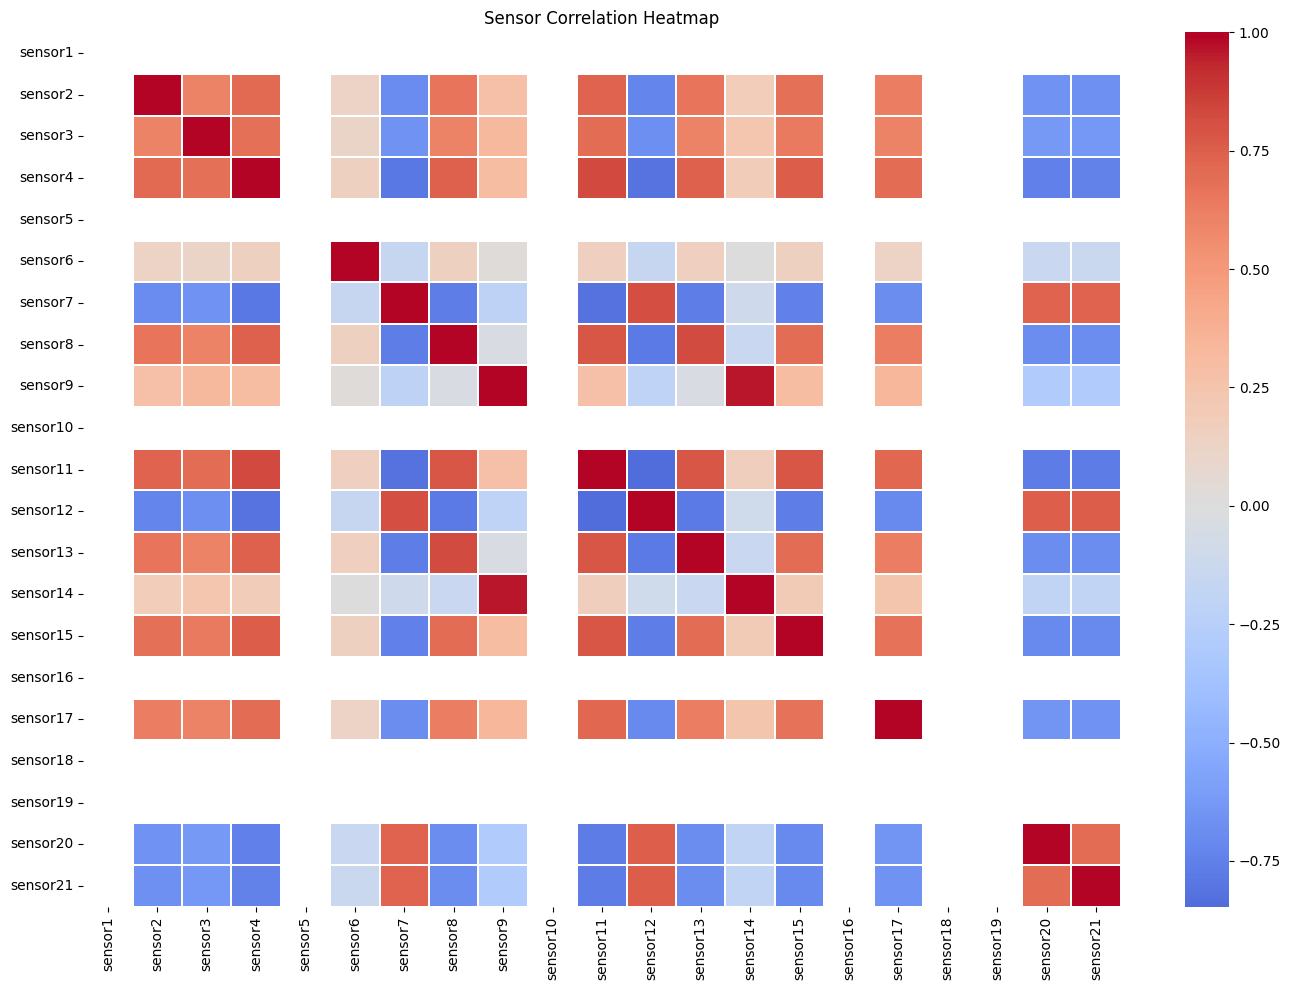

In [ ]:
all_sensor_cols = [f"sensor{i}" for i in range(1, 22)]

plt.figure(figsize=(14, 10))
sns.heatmap(
    train_df[all_sensor_cols].corr(),
    cmap='coolwarm',
    center=0,
    annot=False,
    linewidths=0.3
)
plt.title('Sensor Correlation Heatmap')
plt.tight_layout()
plt.show()

This heatmap shows how strongly each sensor is related to every other sensor. Highly correlated sensors carry the same information, so we can potentially drop some of them.

### RUL Distribution Before vs After Clipping

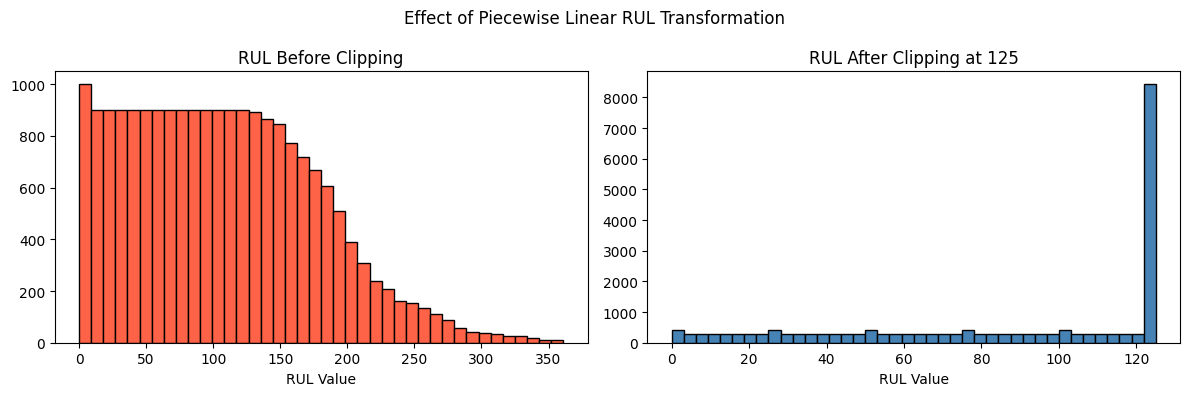

In [ ]:
# Before vs after piecewise linear clipping
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# use transform to align properly with train_df rows
max_per_unit = train_df.groupby('unit')['cycle'].transform('max')
raw_rul      = max_per_unit - train_df['cycle']

axes[0].hist(raw_rul, bins=40, color='tomato', edgecolor='black')
axes[0].set_title('RUL Before Clipping')
axes[0].set_xlabel('RUL Value')

axes[1].hist(train_df['RUL'], bins=40, color='steelblue', edgecolor='black')
axes[1].set_title('RUL After Clipping at 125')
axes[1].set_xlabel('RUL Value')

plt.suptitle('Effect of Piecewise Linear RUL Transformation', fontsize=12)
plt.tight_layout()
plt.show()


We compare the RUL distribution before and after capping at 125. This shows why clipping is important — it makes the prediction problem more realistic and prevents the model from trying to predict extremely large RUL values.

### Train/Validation Split

We split the engines (not individual rows) — 80% of engines go to training, 20% to validation. Splitting by engine ensures the model is tested on engines it has never seen before.

In [ ]:
all_units  = train_df['unit'].unique()
np.random.seed(42)
train_units = np.random.choice(all_units, size=int(0.8 * len(all_units)), replace=False)
val_units   = [u for u in all_units if u not in train_units]
train_data = train_df[train_df['unit'].isin(train_units)]
val_data   = train_df[train_df['unit'].isin(val_units)]

print(f"Train engines: {len(train_units)}, Val engines: {len(val_units)}")

Train engines: 80, Val engines: 20


###  Feature Selection

In [ ]:
all_sensor_cols = [f"sensor{i}" for i in range(1, 22)]

# Fit on training data only
selector = VarianceThreshold(threshold=0.001)
selector.fit(train_data[all_sensor_cols])

# Separate kept vs dropped
good_sensors = [s for s, keep in zip(all_sensor_cols, selector.get_support()) if keep]
good_sensors = [col for col in good_sensors if col != 'sensor9']
dropped      = [s for s in all_sensor_cols if s not in good_sensors]


print(f"Kept   ({len(good_sensors)}): {good_sensors}")
print(f"Dropped ({len(dropped)}):  {dropped}")

Kept   (13): ['sensor2', 'sensor3', 'sensor4', 'sensor7', 'sensor8', 'sensor11', 'sensor12', 'sensor13', 'sensor14', 'sensor15', 'sensor17', 'sensor20', 'sensor21']
Dropped (8):  ['sensor1', 'sensor5', 'sensor6', 'sensor9', 'sensor10', 'sensor16', 'sensor18', 'sensor19']


Some sensors barely change across the entire dataset — they carry almost no useful information. We use a Variance Threshold to automatically detect and remove these flat/constant sensors, keeping only the informative ones.

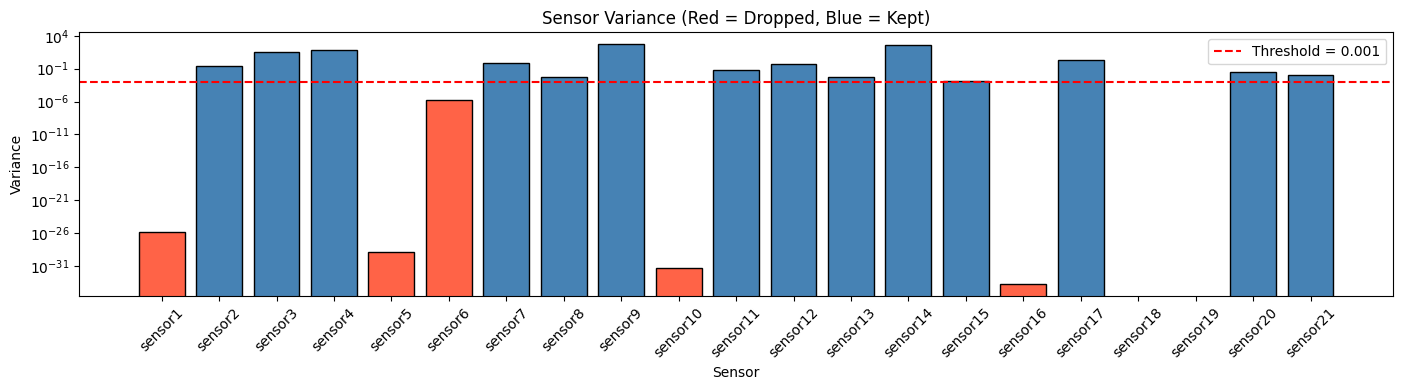

In [ ]:
variances = selector.variances_
plt.figure(figsize=(14, 4))
colors = ['steelblue' if v > 0.001 else 'tomato' for v in variances]
plt.bar(all_sensor_cols, variances, color=colors, edgecolor='black')
plt.axhline(0.001, color='red', linestyle='--', label='Threshold = 0.001')
plt.title('Sensor Variance (Red = Dropped, Blue = Kept)')
plt.xlabel('Sensor')
plt.ylabel('Variance')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.yscale('log')
plt.show()

Most sensors stay almost the same throughout the engine's life and give the model nothing useful to learn. We automatically removed flat sensors with near-zero variance, keeping only the ones that actually change over time. These are the ones that carry the story of engine degradation.

### Normalization & Sequence Creation (Training)
Sensor values have very different ranges (e.g., temperature vs pressure). We scale everything to 0–1 using MinMaxScaler. Then we create sliding windows of 30 cycles — the LSTM looks at the last 30 cycles to predict the RUL at the next cycle.

In [ ]:
feature_cols = ["setting1", "setting2", "setting3"] + good_sensors

scaler = MinMaxScaler()
scaler.fit(train_data[feature_cols])

SEQ_LEN = 30

def create_sequences(data, seq_len, feature_cols):
    X, y = [], []
    for unit in data['unit'].unique():
        unit_df = data[data['unit'] == unit].reset_index(drop=True)
        scaled  = scaler.transform(unit_df[feature_cols])
        rul     = unit_df['RUL'].values
        for i in range(len(unit_df) - seq_len):
            X.append(scaled[i : i + seq_len])
            y.append(rul[i + seq_len])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_data, SEQ_LEN, feature_cols)
X_val,   y_val   = create_sequences(val_data,   SEQ_LEN, feature_cols)

print("X_train shape:", X_train.shape)
print("X_val shape:  ", X_val.shape)

X_train shape: (13940, 30, 16)
X_val shape:   (3691, 30, 16)


###  Test Sequence Creation
For each test engine, we take only its last 30 cycles (or pad if shorter) and predict the RUL at that final point. The true answers come from the RUL_FD001 file.

In [ ]:
def create_test_sequences(data, seq_len, feature_cols):
    X = []
    for unit in sorted(data['unit'].unique()):
        unit_df = data[data['unit'] == unit].reset_index(drop=True)
        scaled  = scaler.transform(unit_df[feature_cols])
        if len(unit_df) >= seq_len:
            X.append(scaled[-seq_len:])       # last 30 cycles only
        else:
            pad = np.zeros((seq_len - len(unit_df), len(feature_cols)))
            X.append(np.vstack([pad, scaled]))
    return np.array(X)

X_test = create_test_sequences(test_df, SEQ_LEN, feature_cols)
y_test = rul_test["true_RUL"].values.clip(max=125)   # real NASA ground truth

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (100, 30, 16)
y_test shape: (100,)


### Build the LSTM Model
We build a stacked LSTM network with two LSTM layers (64 and 32 units)
and two Dropout layers to prevent overfitting. A final Dense layer
outputs a single RUL value. We use Mean Squared Error (MSE) as the
loss function since this is a regression problem.

In [ ]:
# Stacked (2 layers)
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(32))
model.add(Dropout(0.2))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
import tensorflow as tf

def nasa_loss(y_true, y_pred):
    diff = y_pred - y_true
    score = tf.reduce_mean(
        tf.where(diff < 0,
                 tf.exp(-diff / 13) - 1,
                 tf.exp(diff / 10) - 1)
    )
    return score

model.compile(optimizer='adam', loss=nasa_loss)

### Train the Model



In [ ]:
callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=5, verbose=1)
]

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks
)

Epoch 1/50
436/436 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 2342.3066 - val_loss: 1539.9739 - learning_rate: 0.0010
Epoch 2/50
436/436 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 1047.0514 - val_loss: 832.9034 - learning_rate: 0.0010
Epoch 3/50
436/436 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 612.8192 - val_loss: 517.7629 - learning_rate: 0.0010
Epoch 4/50
436/436 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 401.1197 - val_loss: 349.0838 - learning_rate: 0.0010
Epoch 5/50
436/436 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 279.8937 - val_loss: 248.9733 - learning_rate: 0.0010
Epoch 6/50
436/436 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 206.9666 - val_loss: 185.3763 - learning_rate: 0.0010
Epoch 7/50
436/436 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 158.8626 - val_loss: 143.7659 - learning_rate: 0.0010
Epoch 8/50
436/436 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 126.0316 - val_loss: 116.3585 - learning_rate: 0.0010
Epoch 9/50
436/436 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 106.4504 - val_los

The model learns from the training data over multiple passes (epochs). Early Stopping stops training if the model stops improving, and ReduceLROnPlateau automatically lowers the learning rate when progress slows — both help the model converge to a better solution.

In [ ]:
y_pred = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step


### RNN vs LSTM Comparison
Basic RNN is the simpler predecessor of LSTM. LSTM was specifically
designed to fix RNN's weakness of forgetting long-term patterns. Here
we train both and compare — this directly shows why LSTM is the better
choice for RUL prediction.

In [ ]:
rnn_model = Sequential()
rnn_model.add(SimpleRNN(64, input_shape=(SEQ_LEN, X_train.shape[2])))
rnn_model.add(Dropout(0.2))
rnn_model.add(Dense(1))

rnn_model.compile(optimizer='adam', loss='mse')

rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks
)

Epoch 1/50
436/436 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 5022.1001 - val_loss: 3853.1565 - learning_rate: 0.0010
Epoch 2/50
436/436 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2891.3660 - val_loss: 2460.4436 - learning_rate: 0.0010
Epoch 3/50
436/436 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 2077.3530 - val_loss: 1943.5084 - learning_rate: 0.0010
Epoch 4/50
436/436 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1827.2825 - val_loss: 1798.5520 - learning_rate: 0.0010
Epoch 5/50
426/436 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1785.2244
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
436/436 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1774.4189 - val_loss: 1766.8264 - learning_rate: 0.0010
Epoch 6/50
436/436 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1749.5747 - val_loss: 1716.2338 - learning_rate: 5.0000e-04
Epoch 7/50
436/436 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1489.3900 - val_loss: 945.0714 - learning_rate: 5.0000e-04
Epoch 8/50
436/436 ━━━━━━━━━━━━━━━━━━━━ 3s 6m

In [ ]:
rnn_pred = rnn_model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step


In [ ]:
lstm_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rnn_rmse  = np.sqrt(mean_squared_error(y_test, rnn_pred))
lstm_mae  = mean_absolute_error(y_test, y_pred)
rnn_mae   = mean_absolute_error(y_test, rnn_pred)

print("=" * 35)
print(f"{'Model':<10} {'RMSE':>10} {'MAE':>10}")
print("=" * 35)
print(f"{'LSTM':<10} {lstm_rmse:>10.2f} {lstm_mae:>10.2f}")
print(f"{'RNN':<10} {rnn_rmse:>10.2f} {rnn_mae:>10.2f}")
print("=" * 35)

Model            RMSE        MAE
LSTM            13.74      10.14
RNN             55.21      47.40


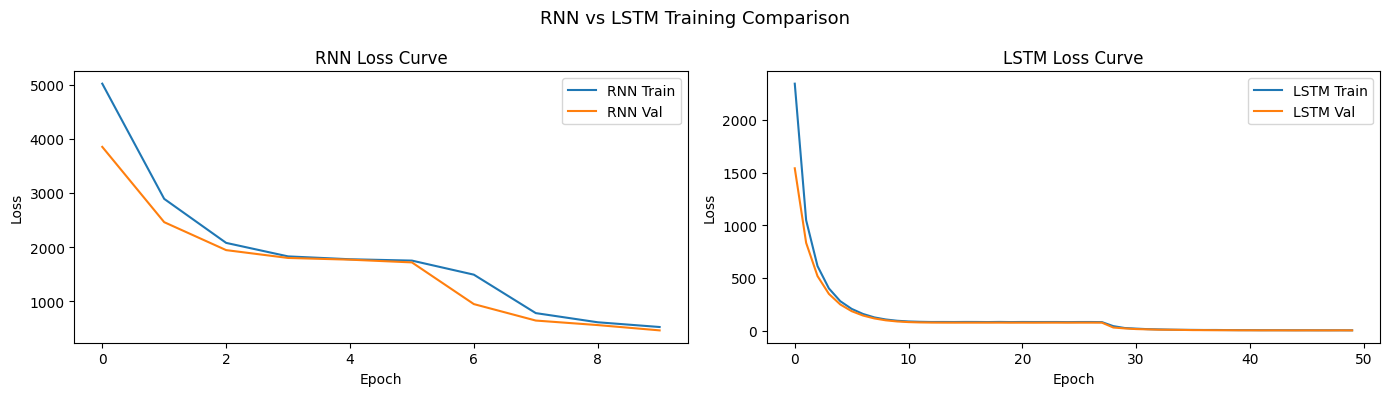

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(rnn_history.history['loss'],     label='RNN Train')
axes[0].plot(rnn_history.history['val_loss'], label='RNN Val')
axes[0].set_title('RNN Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='LSTM Train')
axes[1].plot(history.history['val_loss'], label='LSTM Val')
axes[1].set_title('LSTM Loss Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('RNN vs LSTM Training Comparison', fontsize=13)
plt.tight_layout()
plt.show()

### Monte Carlo Dropout (Uncertainty Estimation)

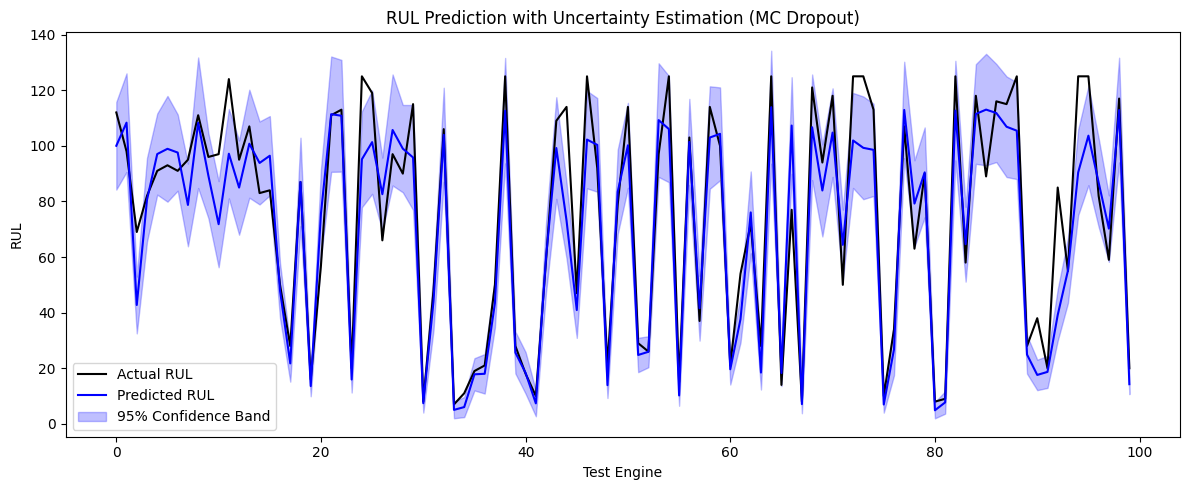

Average uncertainty (std): ±6.53 cycles


In [ ]:
def mc_predict(model, X, n_iter=50):
    preds = np.array([
        model(X, training=True).numpy().flatten()
        for _ in range(n_iter)
    ])
    mean = preds.mean(axis=0)
    std  = preds.std(axis=0)
    return mean, std

mean_pred, uncertainty = mc_predict(model, X_test)

# Plot with confidence bands
plt.figure(figsize=(12, 5))
x = range(len(mean_pred))
plt.plot(y_test,    label='Actual RUL',    color='black',  linewidth=1.5)
plt.plot(mean_pred, label='Predicted RUL', color='blue',   linewidth=1.5)
plt.fill_between(x,
                 mean_pred - 2*uncertainty,
                 mean_pred + 2*uncertainty,
                 alpha=0.25, color='blue', label='95% Confidence Band')
plt.title('RUL Prediction with Uncertainty Estimation (MC Dropout)')
plt.xlabel('Test Engine')
plt.ylabel('RUL')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Average uncertainty (std): ±{uncertainty.mean():.2f} cycles")


Instead of predicting once, we run the model 50 times with Dropout still active (randomly switching off neurons). The average prediction is our final answer, and the variation across runs tells us how confident the model is. Wide confidence bands = uncertain prediction.

### Evaluation Metrics
We evaluate model performance using four metrics: RMSE (average error in cycles), MAE (average absolute error), R² Score (how well predictions explain the variance), and the NASA Scoring Function (an asymmetric metric that penalizes late predictions — predicting failure too late is worse than predicting it too early in real aerospace engineering).

In [ ]:
def nasa_score(y_true, y_pred):
    diff = y_pred.flatten() - y_true
    return np.sum(np.where(diff < 0, np.exp(-diff/13)-1, np.exp(diff/10)-1))

print(f"RMSE      : {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"MAE       : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"R² Score  : {r2_score(y_test, y_pred):.3f}")
print(f"NASA Score: {nasa_score(y_test, y_pred):.1f}")

RMSE      : 13.74
MAE       : 10.14
R² Score  : 0.882
NASA Score: 240.7


### Training Loss Curve

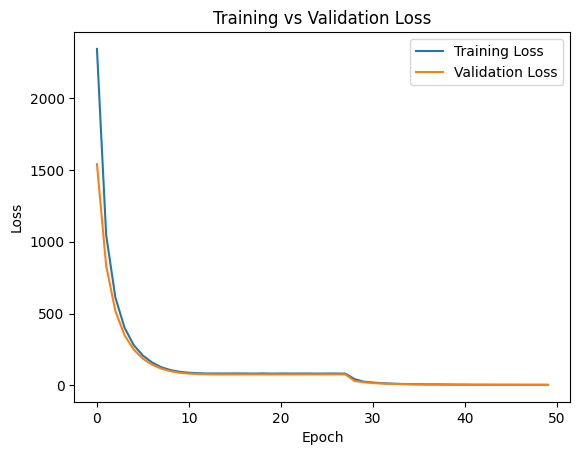

In [ ]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Training Loss", "Validation Loss"])

plt.show()

This graph shows how the model's error decreased over training. Ideally, both training and validation loss should decrease together. If training loss goes down but validation goes up, the model is overfitting.

### Residual Distribution

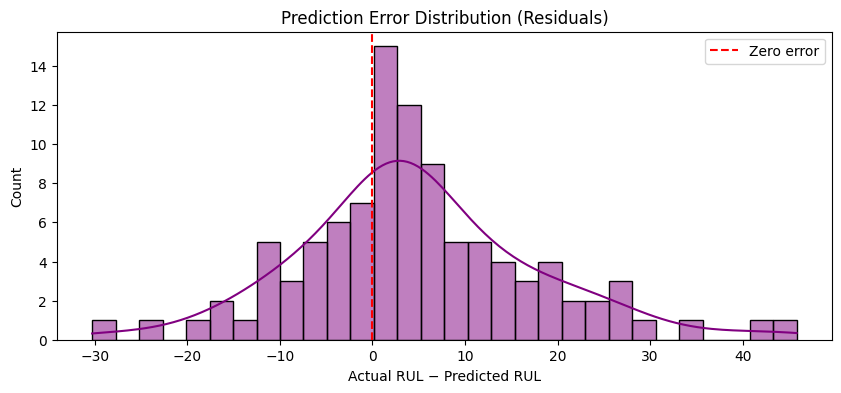

Mean error: 4.79 (positive = under-predicting failure)


In [ ]:
residuals = y_test - mean_pred

plt.figure(figsize=(10, 4))
sns.histplot(residuals, bins=30, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--', label='Zero error')
plt.title('Prediction Error Distribution (Residuals)')
plt.xlabel('Actual RUL − Predicted RUL')
plt.ylabel('Count')
plt.legend()
plt.show()

print(f"Mean error: {residuals.mean():.2f} (positive = under-predicting failure)")

A residual is the difference between the actual and predicted RUL. A good model has residuals centered around zero. If the distribution is skewed, the model is systematically over- or under-predicting.

### Actual vs Predicted Plot

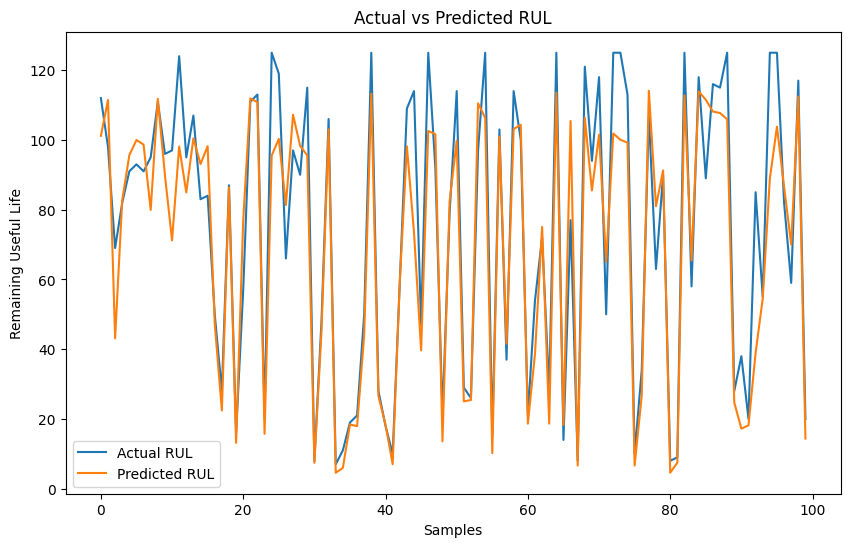

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(y_test[:100], label="Actual RUL")
plt.plot(y_pred[:100], label="Predicted RUL")
plt.title("Actual vs Predicted RUL")
plt.xlabel("Samples")
plt.ylabel("Remaining Useful Life")
plt.legend()
plt.show()

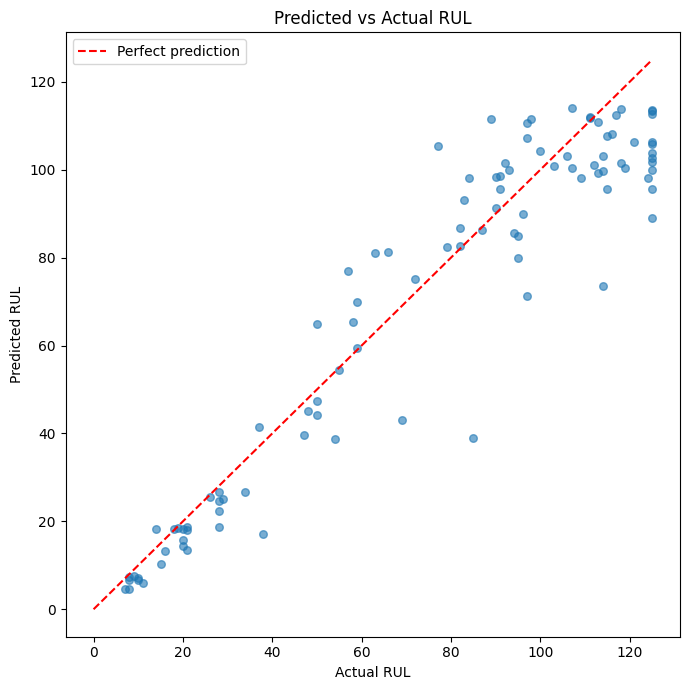

In [ ]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.6, s=30)
plt.plot([0, 125], [0, 125], 'r--', label='Perfect prediction')
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Predicted vs Actual RUL")
plt.legend()
plt.tight_layout()
plt.show()